# Методичка

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=10000, n_features=500,
                           n_informative=50, n_repeated=0,
                           class_sep=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=3)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression().fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8413
Test score: 0.8056


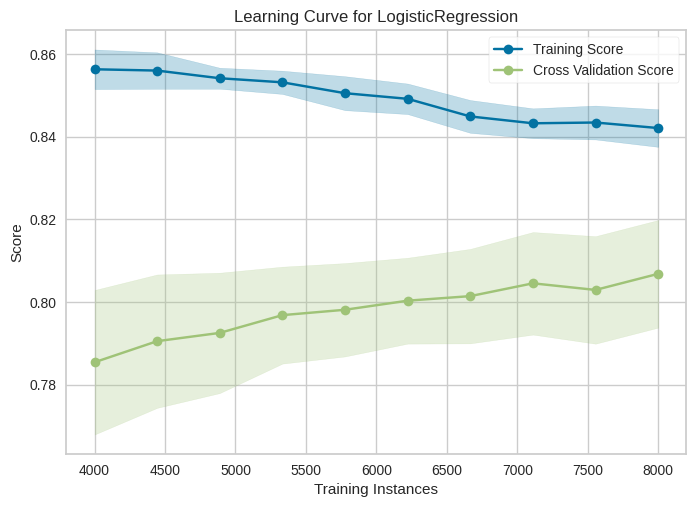

In [ ]:
from yellowbrick.model_selection import LearningCurve

visualizer = LearningCurve(
    LogisticRegression(), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

In [ ]:
from sklearn.linear_model import RidgeClassifier
lr = RidgeClassifier(alpha=1000000).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.7724
Test score: 0.7712


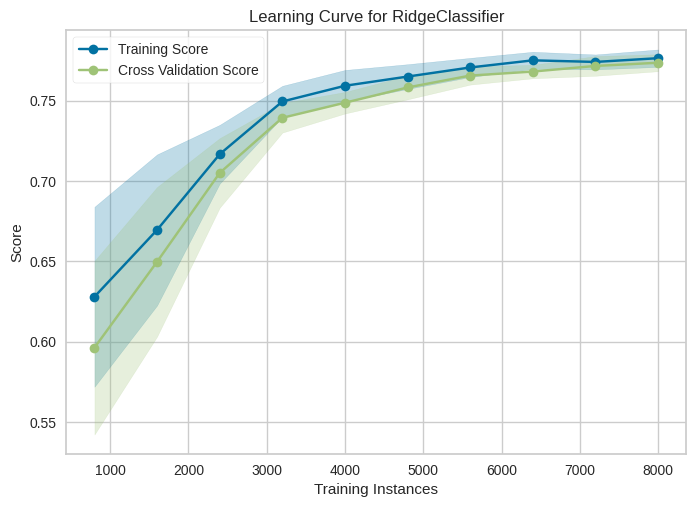

In [ ]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=1000000), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

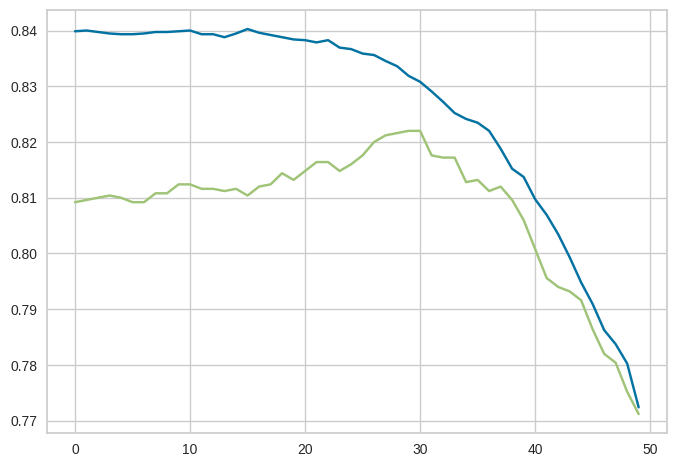

In [ ]:
from sklearn.linear_model import RidgeClassifier
trains = []
tests = []
for i in np.logspace(2, 6, 50):
  ridge = RidgeClassifier(alpha=i).fit(X_train, y_train)
  trains.append(ridge.score(X_train, y_train))
  tests.append(ridge.score(X_test, y_test))

plt.plot(trains)
plt.plot(tests)

In [ ]:
print(np.logspace(2, 6, 50)[30])  # Примерно 26500

28117.68697974225


In [ ]:
from sklearn.linear_model import RidgeClassifier
lr = RidgeClassifier(alpha=28117).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8308
Test score: 0.8220


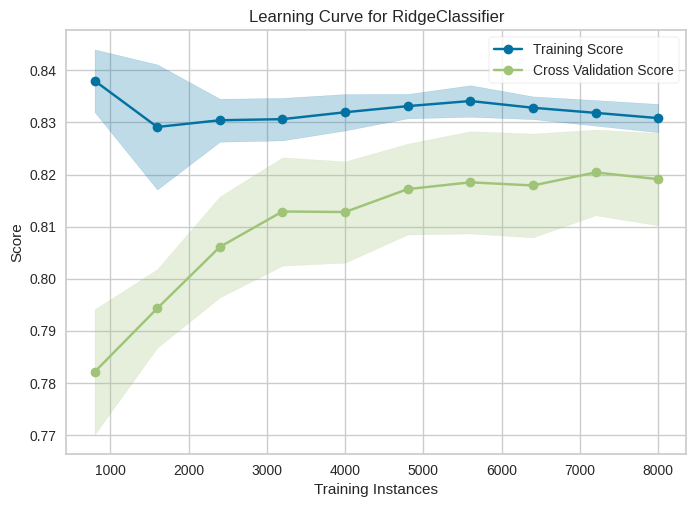

In [ ]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=28117), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

## Диагностика моделей регрессии

In [ ]:
boston = pd.read_csv('BostonHousing.csv')
y = boston['medv']
X = boston.drop('medv', axis=1)

In [ ]:
X.shape

(506, 13)

In [ ]:
X['rm'] = X['rm'].fillna(X['rm'].mean())
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
linr = LinearRegression().fit(X_train_poly, y_train)

print(f"Training score: {linr.score(X_train_poly, y_train):.2f}")
print(f"Test score: {linr.score(X_test_poly, y_test):.2f}")

Training score: 0.93
Test score: 0.81


In [ ]:
X_poly = poly.transform(X)

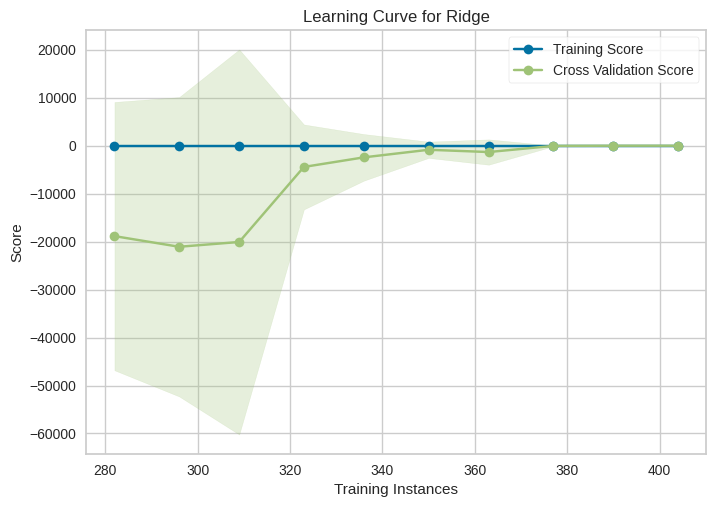

In [ ]:
from yellowbrick.model_selection import LearningCurve
visualizer = LearningCurve(
    Ridge(alpha=0.1), scoring='r2', train_sizes=np.linspace(0.7, 1.0, 10)
).fit(X_poly, y) .show()

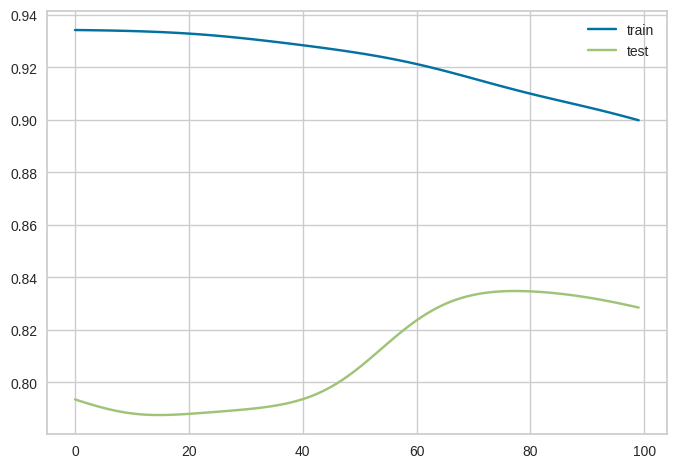

In [ ]:
from sklearn.linear_model import Ridge
trains = []
tests = []
for i in np.logspace(-2, 3, 100):
  ridge = Ridge(alpha=i).fit(X_train_poly, y_train)
  trains.append(ridge.score(X_train_poly, y_train))
  tests.append(ridge.score(X_test_poly, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

In [ ]:
np.logspace(-2, 3, 100)[80]

109.74987654930568

In [ ]:
lr = Ridge(alpha=109.7).fit(X_train_poly, y_train)

print(f"Linear Regression-Training set score: {lr.score(X_train_poly, y_train):.2f}")
print(f"Linear Regression-Test set score: {lr.score(X_test_poly, y_test):.2f}")

Linear Regression-Training set score: 0.91
Linear Regression-Test set score: 0.83


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.265e+03, tolerance: 3.623e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.267e+03, tolerance: 3.623e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.269e+03, tolerance: 3.623e

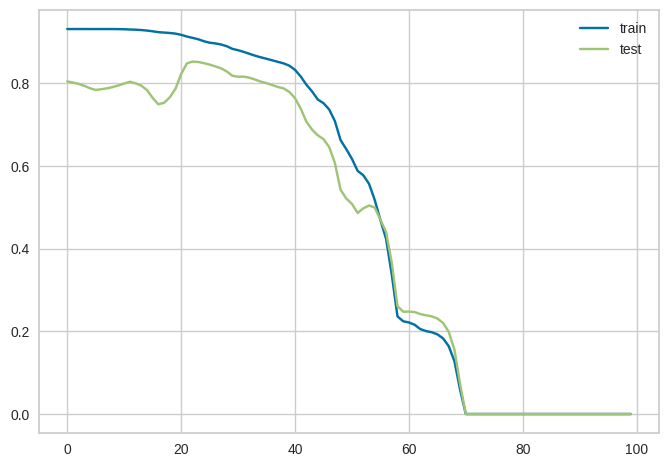

In [ ]:
from sklearn.linear_model import Lasso
trains = []
tests = []
for i in np.logspace(-4, 10, 100):
  lasso = Lasso(alpha=i, max_iter=10000).fit(X_train_poly, y_train)
  trains.append(lasso.score(X_train_poly, y_train))
  tests.append(lasso.score(X_test_poly, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

In [ ]:
np.logspace(-4, 10, 100)[23]

0.1788649529057435

In [ ]:
lr = Lasso(alpha=0.178).fit(X_train_poly, y_train)

print(f"Linear Regression-Training set score: {lr.score(X_train_poly, y_train):.2f}")
print(f"Linear Regression-Test set score: {lr.score(X_test_poly, y_test):.2f}")

Linear Regression-Training set score: 0.90
Linear Regression-Test set score: 0.84


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.021e+03, tolerance: 3.623e+00
  model = cd_fast.enet_coordinate_descent(


## Диагностика на реальных данных

In [ ]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv',nrows=200)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 1.0000
Test score = 0.5500


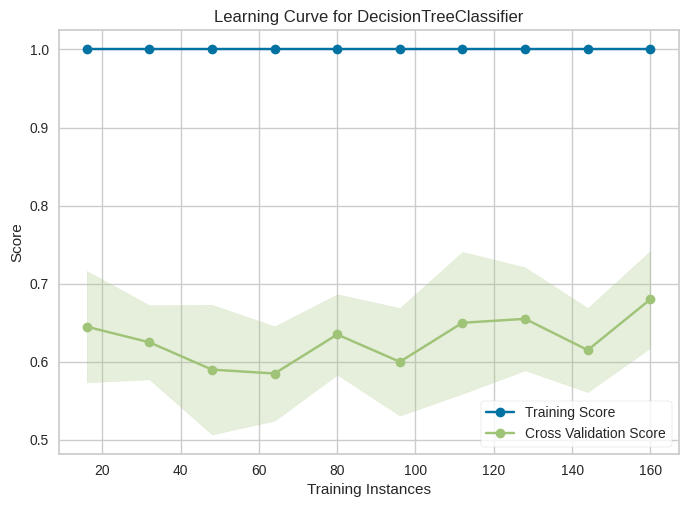

In [ ]:
visualizer = LearningCurve(
    DecisionTreeClassifier(), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

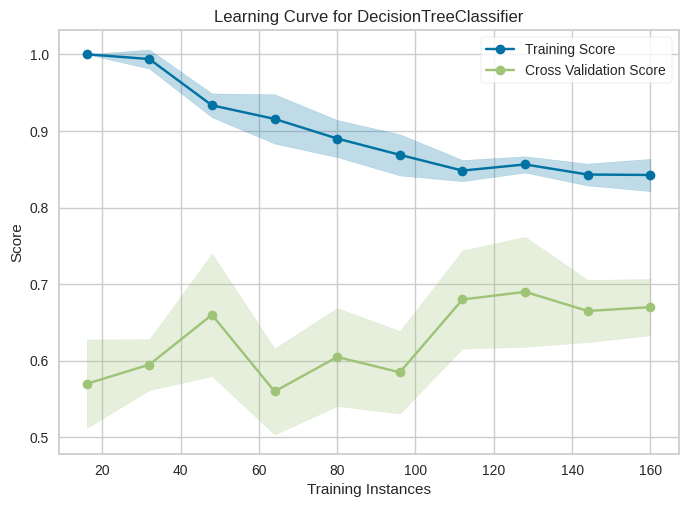

In [ ]:
visualizer = LearningCurve(
    DecisionTreeClassifier(max_depth=4), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

In [ ]:
model = DecisionTreeClassifier(max_depth=4, random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.8500
Test score = 0.6250


In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv')
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
from sklearn.metrics import f1_score
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 1.0000
Test score = 0.7273


## Диагностика недообучения

In [ ]:
from sklearn.datasets import fetch_openml
data = fetch_openml(name='delta_ailerons', parser="auto")
data.data.shape

(7129, 5)

In [ ]:
X = pd.get_dummies(data.data)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.6092
Test score = 0.5989


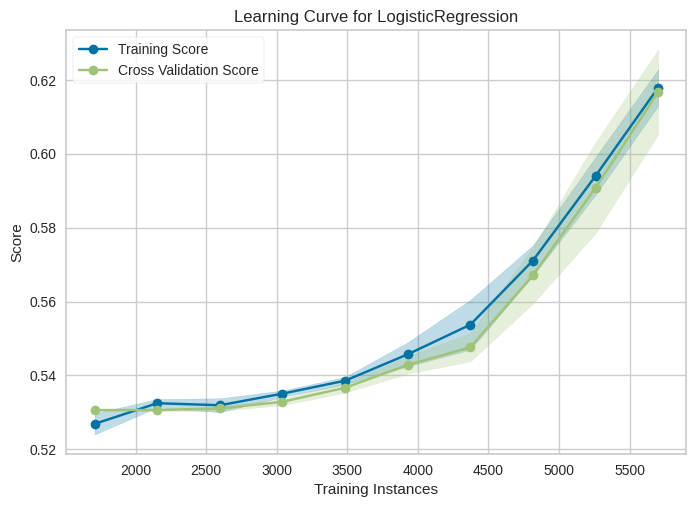

In [ ]:
visualizer = LearningCurve(
    LogisticRegression(), scoring='accuracy', train_sizes=np.linspace(0.3, 1.0, 10)
).fit(X, y) .show()

In [ ]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier().fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9386
Test score = 0.9404


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

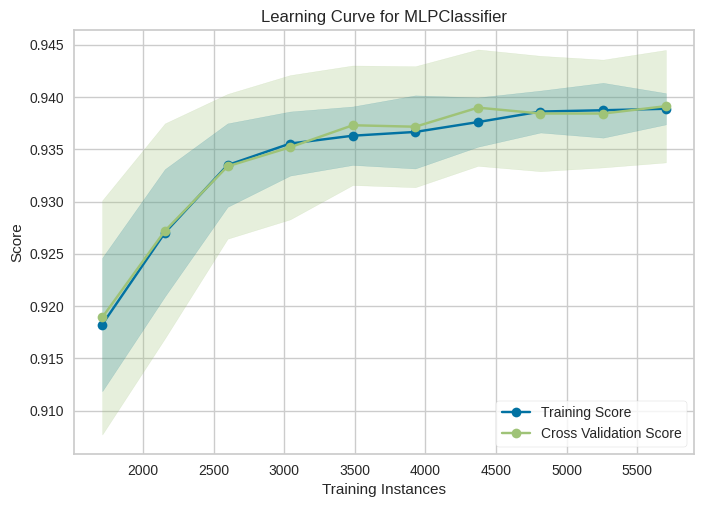

In [ ]:
visualizer = LearningCurve(
    MLPClassifier(), scoring='accuracy', train_sizes=np.linspace(0.3, 1.0, 10)
).fit(X, y) .show()

# Домашняя работа

# 1. Повторите диагностику модели классификации синтетических данных с использованием других метрик эффективности - precision, recall, F1. Как изменились результаты?

In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=10000, n_features=500,
                           n_informative=50, n_repeated=0,
                           class_sep=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=3)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
lr = LogisticRegression().fit(X_train, y_train)

print(f"Training preceison: {precision_score(lr.predict(X_train), y_train):.4f}")
print(f"Test precison: {precision_score(lr.predict(X_test), y_test):.4f}")
print('-------------------')
print(f"Training preceison: {recall_score(lr.predict(X_train), y_train):.4f}")
print(f"Test precison: {recall_score(lr.predict(X_test), y_test):.4f}")
print('-------------------')
print(f"Training preceison: {f1_score(lr.predict(X_train), y_train):.4f}")
print(f"Test precison: {f1_score(lr.predict(X_test), y_test):.4f}")

Training preceison: 0.8515
Test precison: 0.8056
-------------------
Training preceison: 0.8337
Test precison: 0.8069
-------------------
Training preceison: 0.8425
Test precison: 0.8062


precision


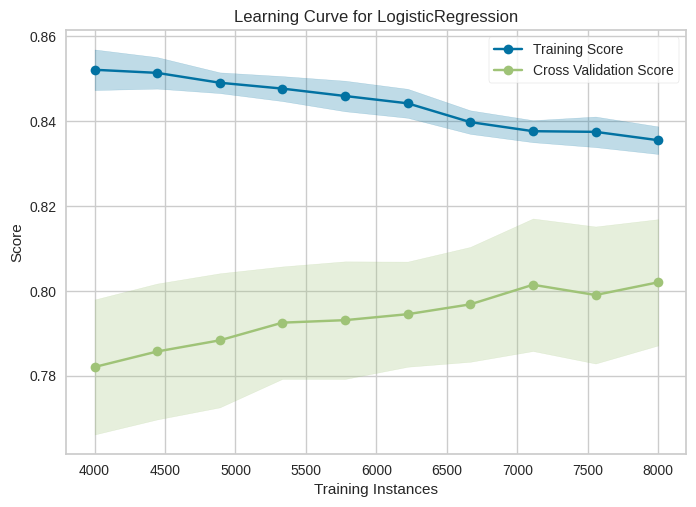

In [ ]:
from yellowbrick.model_selection import LearningCurve

print('precision')
visualizer = LearningCurve(
    LogisticRegression(), scoring='precision', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

recall


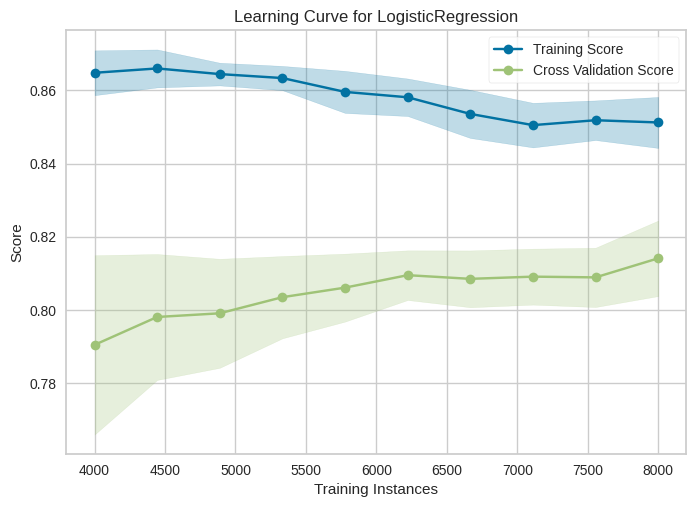

In [ ]:
print('recall')
visualizer = LearningCurve(
    LogisticRegression(), scoring='recall', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

f1


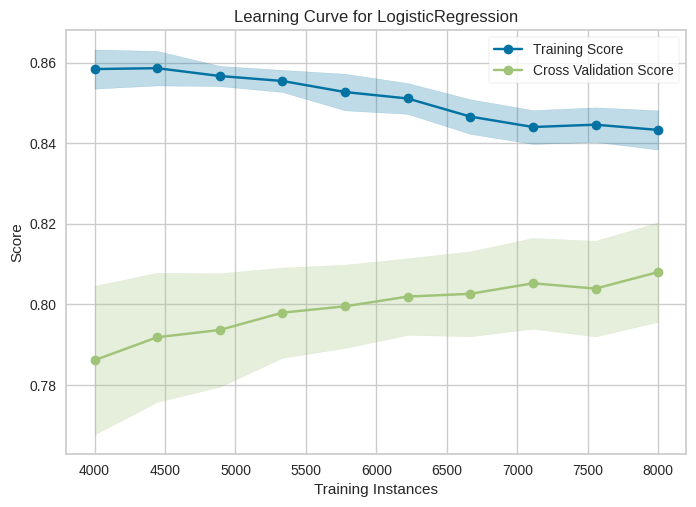

In [ ]:
print('f1')
visualizer = LearningCurve(
    LogisticRegression(), scoring='f1', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

In [ ]:
from sklearn.linear_model import RidgeClassifier
lr = RidgeClassifier(alpha=1000000).fit(X_train, y_train)

print(f"Training preceison: {precision_score(lr.predict(X_train), y_train):.4f}")
print(f"Test precison: {precision_score(lr.predict(X_test), y_test):.4f}")
print('-------------------')
print(f"Training preceison: {recall_score(lr.predict(X_train), y_train):.4f}")
print(f"Test precison: {recall_score(lr.predict(X_test), y_test):.4f}")
print('-------------------')
print(f"Training preceison: {f1_score(lr.predict(X_train), y_train):.4f}")
print(f"Test precison: {f1_score(lr.predict(X_test), y_test):.4f}")

Training preceison: 0.7780
Test precison: 0.7801
-------------------
Training preceison: 0.7683
Test precison: 0.7678
-------------------
Training preceison: 0.7731
Test precison: 0.7739


precision


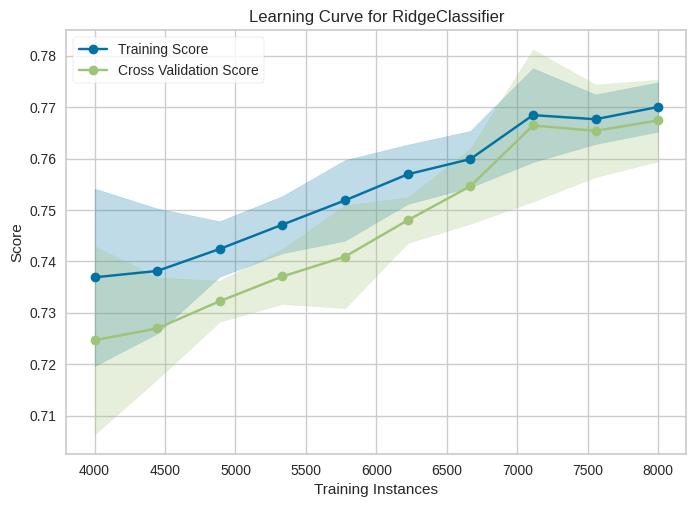

recall


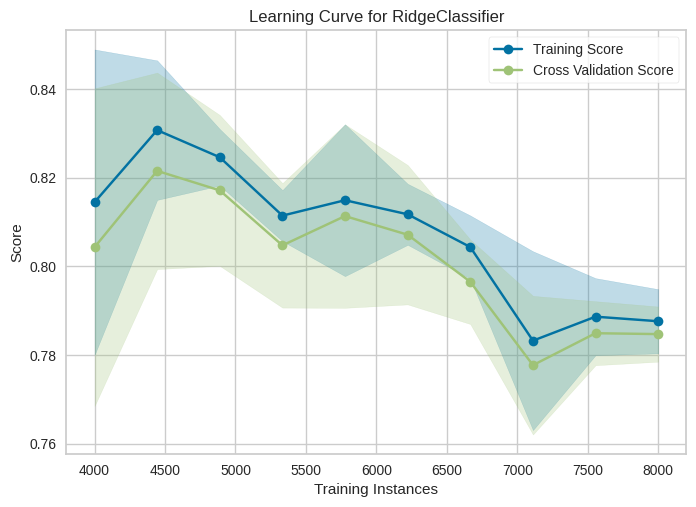

f1


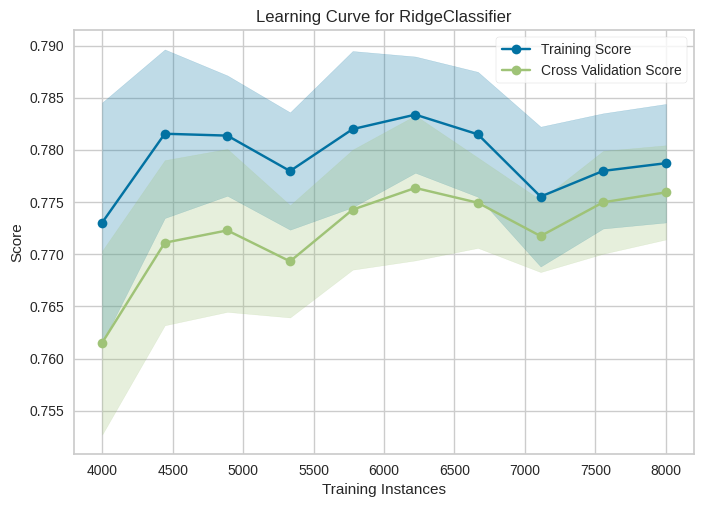

In [ ]:
print('precision')
visualizer = LearningCurve(
    RidgeClassifier(alpha=1000000), scoring='precision', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

print('recall')
visualizer = LearningCurve(
    RidgeClassifier(alpha=1000000), scoring='recall', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

print('f1')
visualizer = LearningCurve(
    RidgeClassifier(alpha=1000000), scoring='f1', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

precision


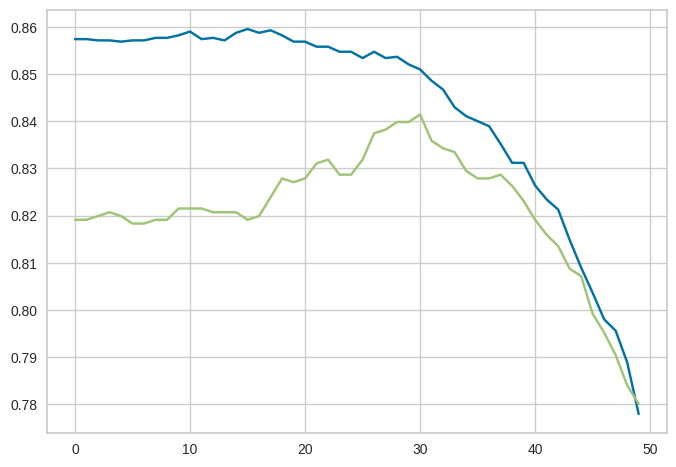

In [ ]:
from sklearn.linear_model import RidgeClassifier
trains = []
tests = []
print('precision')
for i in np.logspace(2, 6, 50):
    ridge = RidgeClassifier(alpha=i).fit(X_train, y_train)
    trains.append(precision_score(ridge.predict(X_train), y_train))
    tests.append(precision_score(ridge.predict(X_test), y_test))

plt.plot(trains)
plt.plot(tests)

recall


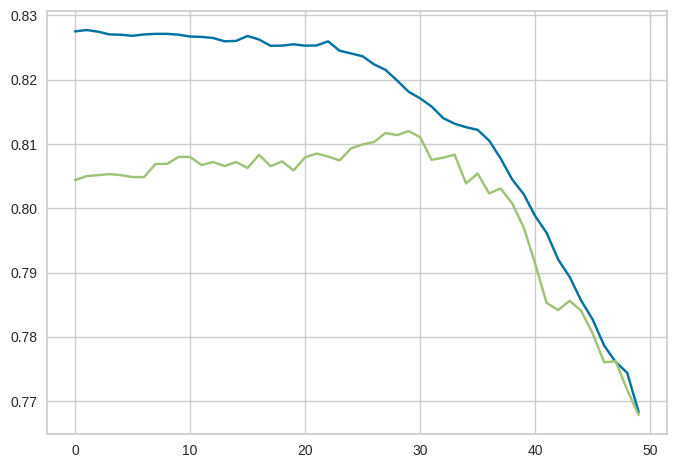

In [ ]:
trains = []
tests = []
print('recall')
for i in np.logspace(2, 6, 50):
    ridge = RidgeClassifier(alpha=i).fit(X_train, y_train)
    trains.append(recall_score(ridge.predict(X_train), y_train))
    tests.append(recall_score(ridge.predict(X_test), y_test))

plt.plot(trains)
plt.plot(tests)

f1


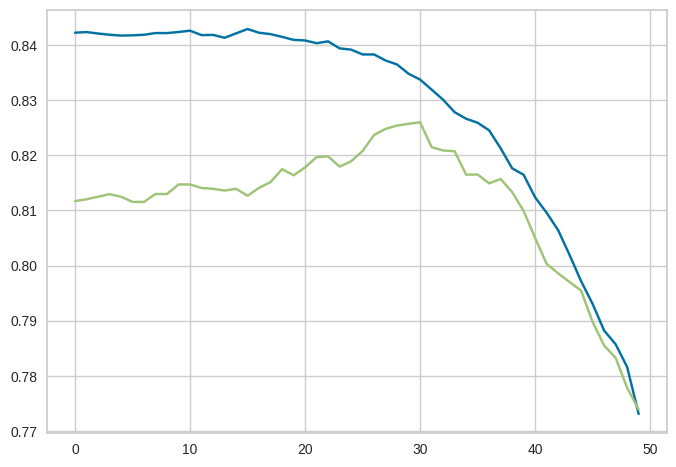

In [ ]:
trains = []
tests = []
print('f1')
for i in np.logspace(2, 6, 50):
    ridge = RidgeClassifier(alpha=i).fit(X_train, y_train)
    trains.append(f1_score(ridge.predict(X_train), y_train))
    tests.append(f1_score(ridge.predict(X_test), y_test))

plt.plot(trains)
plt.plot(tests)

In [ ]:
lr = RidgeClassifier(alpha=26500).fit(X_train, y_train)

print(f"Training preceison: {precision_score(lr.predict(X_train), y_train):.4f}")
print(f"Test precison: {precision_score(lr.predict(X_test), y_test):.4f}")
print('-------------------')
print(f"Training preceison: {recall_score(lr.predict(X_train), y_train):.4f}")
print(f"Test precison: {recall_score(lr.predict(X_test), y_test):.4f}")
print('-------------------')
print(f"Training preceison: {f1_score(lr.predict(X_train), y_train):.4f}")
print(f"Test precison: {f1_score(lr.predict(X_test), y_test):.4f}")

Training preceison: 0.8513
Test precison: 0.8414
-------------------
Training preceison: 0.8174
Test precison: 0.8123
-------------------
Training preceison: 0.8340
Test precison: 0.8266


precision


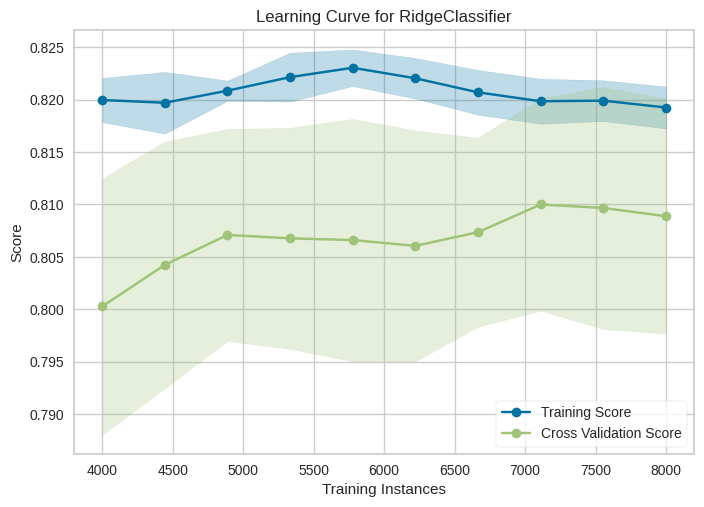

recall


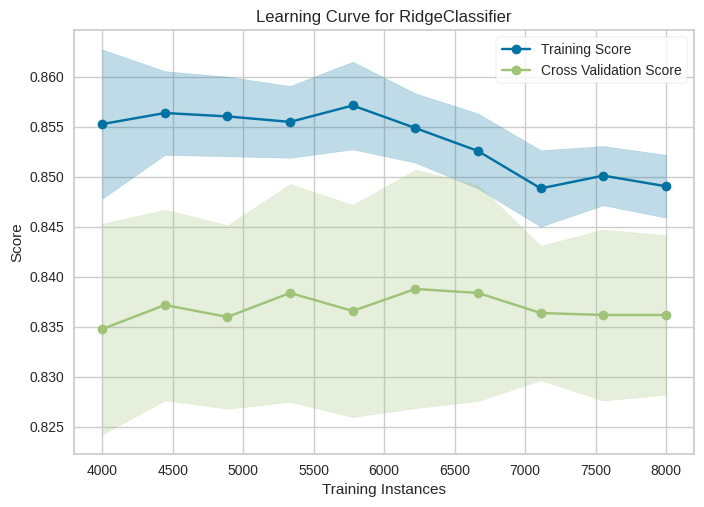

f1


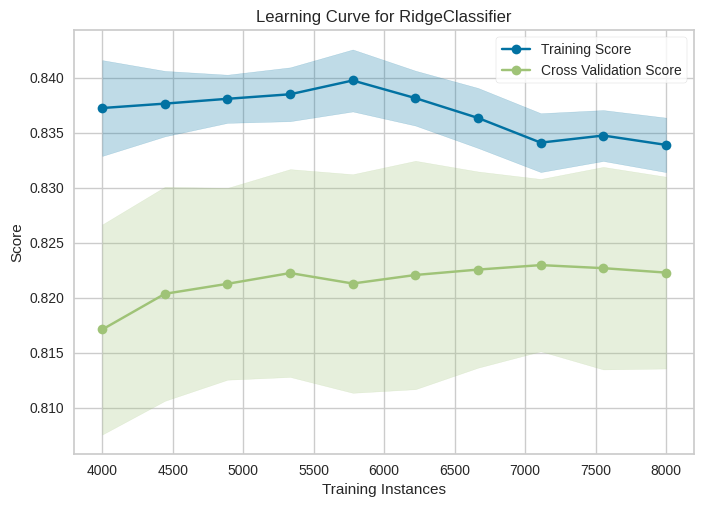

In [ ]:
print('precision')
visualizer = LearningCurve(
    RidgeClassifier(alpha=26500), scoring='precision', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

print('recall')
visualizer = LearningCurve(
    RidgeClassifier(alpha=26500), scoring='recall', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

print('f1')
visualizer = LearningCurve(
    RidgeClassifier(alpha=26500), scoring='f1', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

## 2. Повторите диагностику модели регрессии с использованием других видов моделей:
- метода опорных векторов (исследуйте влияние параметра С на недо-и переобучение)
- метода ближайших соседей (исследуйте влияние количества соседей)
- метода решающих деревьев (гиперпараметры по вашему выбору)

In [ ]:
boston = pd.read_csv('BostonHousing.csv')
y = boston['medv']
X = boston.drop('medv', axis=1)

In [ ]:
X['rm'] = X['rm'].fillna(X['rm'].mean())
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

In [ ]:
from sklearn.svm import SVR

svr_model_1 = SVR(kernel='linear', C=1.0).fit(X_train, y_train)
svr_model_2 = SVR(kernel='linear', C=5.0).fit(X_train, y_train)
svr_model_3 = SVR(kernel='linear', C=10.0).fit(X_train, y_train)

print('C = 1')
print(f"Training score: {svr_model_1.score(X_train, y_train):.4f}")
print(f"Test score: {svr_model_1.score(X_test, y_test):.4f}")
print('C = 5')
print(f"Training score: {svr_model_2.score(X_train, y_train):.4f}")
print(f"Test score: {svr_model_2.score(X_test, y_test):.4f}")
print('C = 10')
print(f"Training score: {svr_model_3.score(X_train, y_train):.4f}")
print(f"Test score: {svr_model_3.score(X_test, y_test):.4f}")

C = 1
Training score: 0.6971
Test score: 0.7043
C = 5
Training score: 0.6845
Test score: 0.6937
C = 10
Training score: 0.6883
Test score: 0.6908


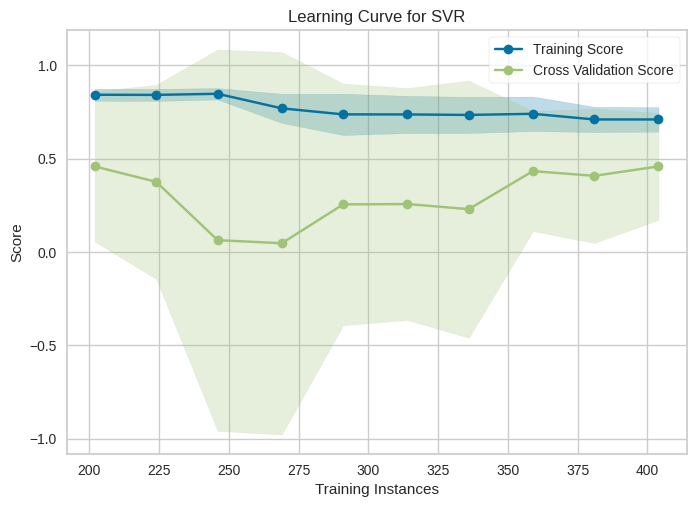

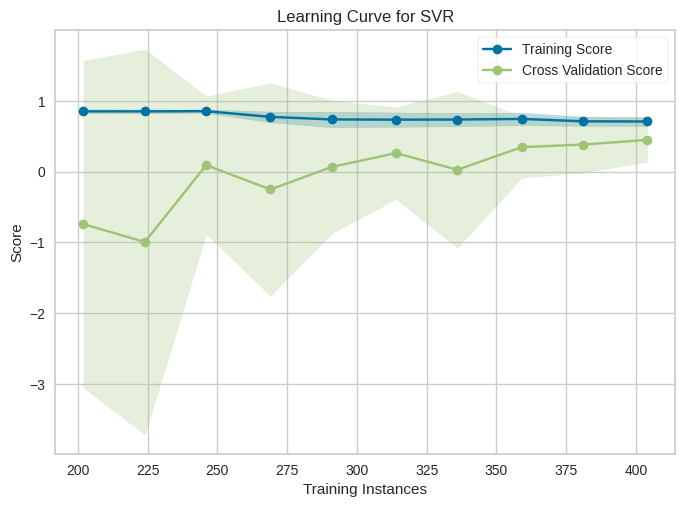

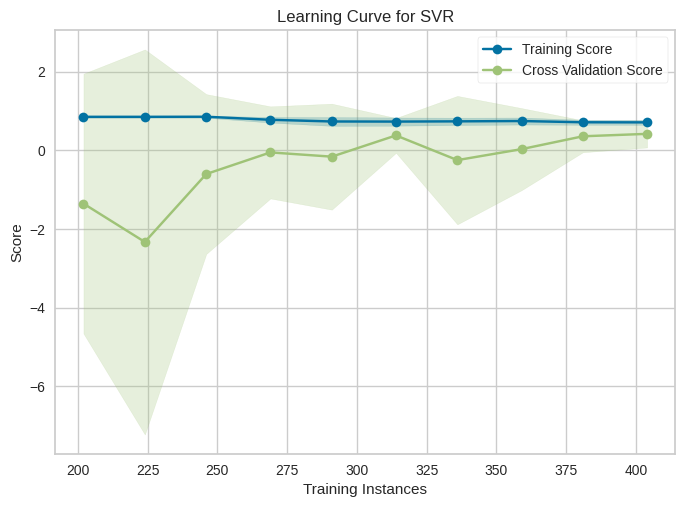

In [ ]:
from yellowbrick.model_selection import LearningCurve

visualizer = LearningCurve(
    SVR(kernel='linear', C=1.0), scoring='r2', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show()

visualizer = LearningCurve(
    SVR(kernel='linear', C=5.0), scoring='r2', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show()

visualizer = LearningCurve(
    SVR(kernel='linear', C=10.0), scoring='r2', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show()

In [ ]:
svr_model = SVR(kernel='linear', C=55.0).fit(X_train, y_train)

print(f"Training score: {svr_model.score(X_train, y_train):.4f}")
print(f"Test score: {svr_model.score(X_test, y_test):.4f}")

Training score: 0.6677
Test score: 0.6483


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn_model_1 = KNeighborsRegressor(n_neighbors=3).fit(X_train, y_train)
knn_model_2 = KNeighborsRegressor(n_neighbors=5).fit(X_train, y_train)
knn_model_3 = KNeighborsRegressor(n_neighbors=7).fit(X_train, y_train)
knn_model_4 = KNeighborsRegressor(n_neighbors=9).fit(X_train, y_train)

print('n_neighbors = 3')
print(f"Training score: {knn_model_1.score(X_train, y_train):.4f}")
print(f"Test score: {knn_model_1.score(X_test, y_test):.4f}")
print('n_neighbors = 5')
print(f"Training score: {knn_model_2.score(X_train, y_train):.4f}")
print(f"Test score: {knn_model_2.score(X_test, y_test):.4f}")
print('n_neighbors = 7')
print(f"Training score: {knn_model_3.score(X_train, y_train):.4f}")
print(f"Test score: {knn_model_3.score(X_test, y_test):.4f}")
print('n_neighbors = 10')
print(f"Training score: {knn_model_4.score(X_train, y_train):.4f}")
print(f"Test score: {knn_model_4.score(X_test, y_test):.4f}")

n_neighbors = 3
Training score: 0.8253
Test score: 0.1802
n_neighbors = 5
Training score: 0.7327
Test score: 0.3403
n_neighbors = 7
Training score: 0.6677
Test score: 0.3409
n_neighbors = 10
Training score: 0.6180
Test score: 0.3271


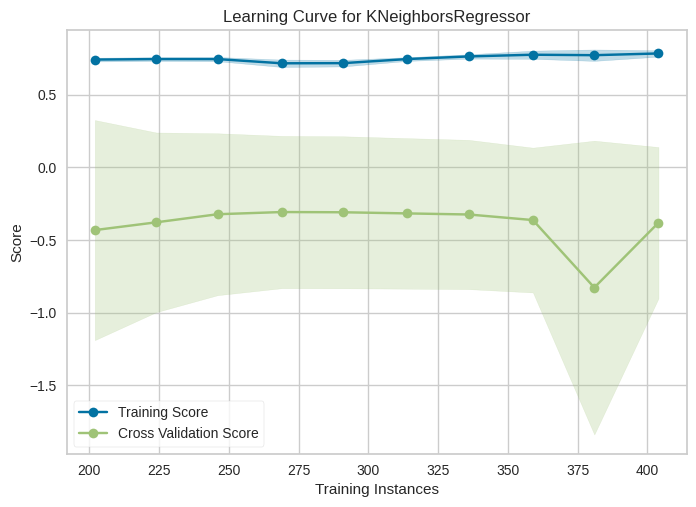

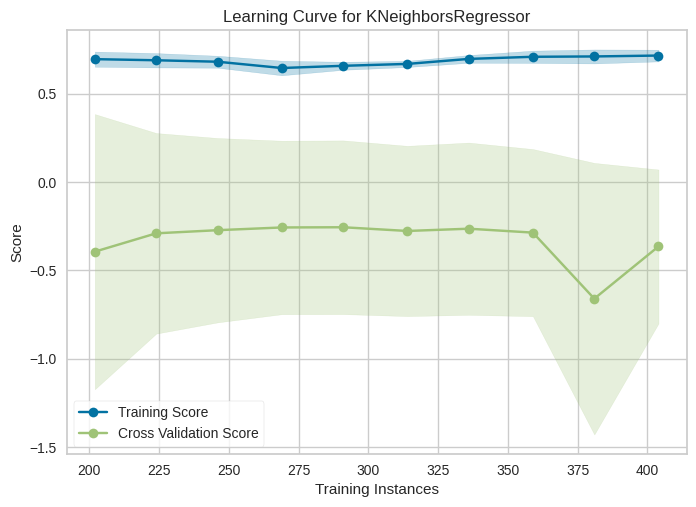

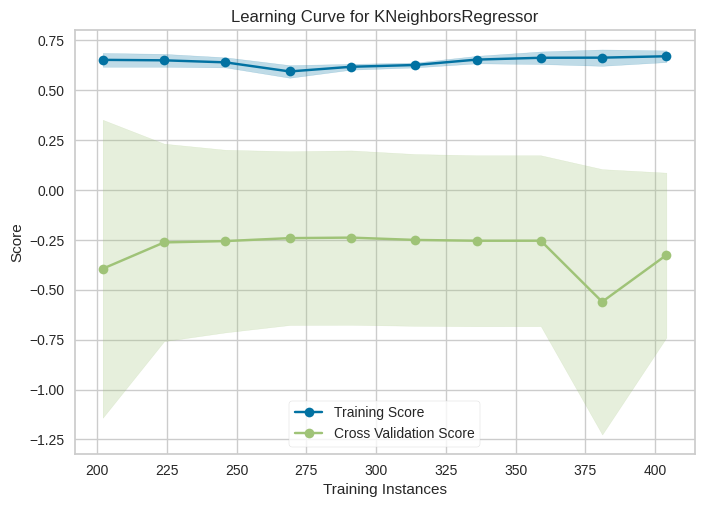

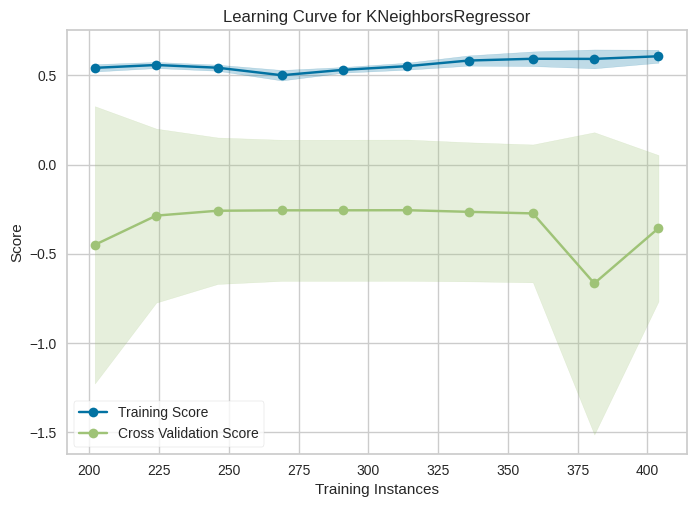

In [ ]:
visualizer = LearningCurve(
    KNeighborsRegressor(n_neighbors=3), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show()

visualizer = LearningCurve(
    KNeighborsRegressor(n_neighbors=5), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show()

visualizer = LearningCurve(
    KNeighborsRegressor(n_neighbors=7), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show()

visualizer = LearningCurve(
    KNeighborsRegressor(n_neighbors=10), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show()

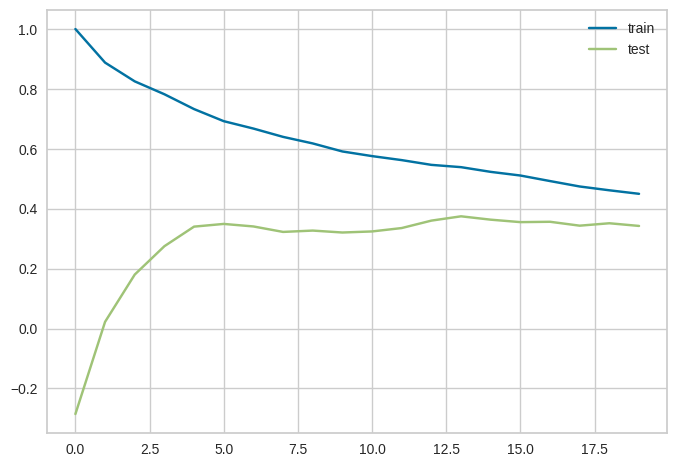

In [ ]:
trains = []
tests = []
for i in np.linspace(1, 20, 20):
    knn_model_1 = KNeighborsRegressor(n_neighbors=int(i)).fit(X_train, y_train)
    trains.append(knn_model_1.score(X_train, y_train))
    tests.append(knn_model_1.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend();

In [ ]:
knn_model = KNeighborsRegressor(n_neighbors=14).fit(X_train, y_train)

print(f"Training score: {knn_model.score(X_train, y_train):.4f}")
print(f"Test score: {knn_model.score(X_test, y_test):.4f}")

Training score: 0.5388
Test score: 0.3747


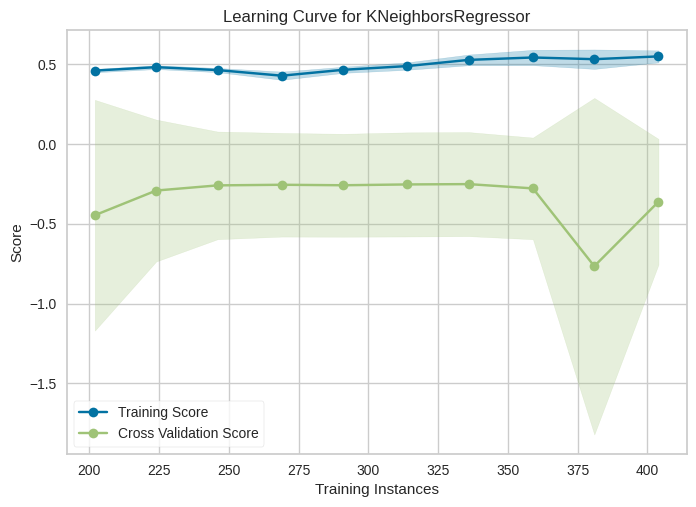

In [ ]:
visualizer = LearningCurve(
    KNeighborsRegressor(n_neighbors=14), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_model_1 = DecisionTreeRegressor(max_depth=3).fit(X_train, y_train)
dt_model_2 = DecisionTreeRegressor(max_depth=5).fit(X_train, y_train)
dt_model_3 = DecisionTreeRegressor(max_depth=7).fit(X_train, y_train)
dt_model_4 = DecisionTreeRegressor(max_depth=10).fit(X_train, y_train)

print('max_depth = 3')
print(f"Training score: {dt_model_1.score(X_train, y_train):.4f}")
print(f"Test score: {knn_model_1.score(X_test, y_test):.4f}")
print('max_depth = 5')
print(f"Training score: {dt_model_2.score(X_train, y_train):.4f}")
print(f"Test score: {knn_model_2.score(X_test, y_test):.4f}")
print('max_depth = 7')
print(f"Training score: {dt_model_3.score(X_train, y_train):.4f}")
print(f"Test score: {knn_model_3.score(X_test, y_test):.4f}")
print('max_depth = 10')
print(f"Training score: {dt_model_4.score(X_train, y_train):.4f}")
print(f"Test score: {knn_model_4.score(X_test, y_test):.4f}")

max_depth = 3
Training score: 0.8250
Test score: 0.3426
max_depth = 5
Training score: 0.9315
Test score: 0.3403
max_depth = 7
Training score: 0.9634
Test score: 0.3409
max_depth = 10
Training score: 0.9923
Test score: 0.3271


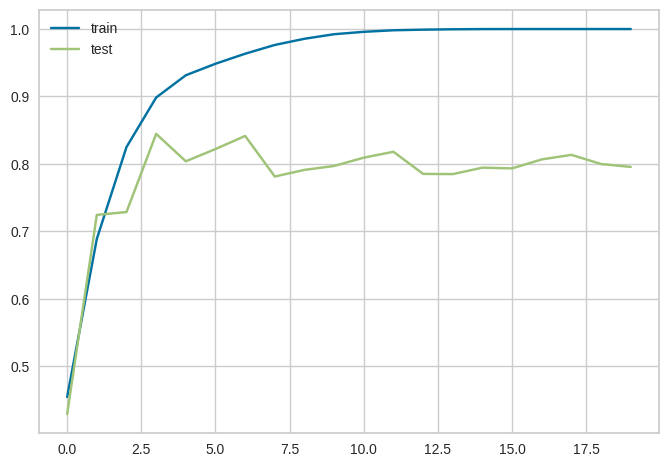

In [ ]:
trains = []
tests = []
for i in np.linspace(1, 20, 20):
    dt_model = DecisionTreeRegressor(max_depth=int(i)).fit(X_train, y_train)
    trains.append(dt_model.score(X_train, y_train))
    tests.append(dt_model.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend();

In [ ]:
dt_model = DecisionTreeRegressor(max_depth=4).fit(X_train, y_train)

print('max_depth = 4')
print(f"Training score: {dt_model.score(X_train, y_train):.4f}")
print(f"Test score: {dt_model.score(X_test, y_test):.4f}")

max_depth = 4
Training score: 0.8985
Test score: 0.8107


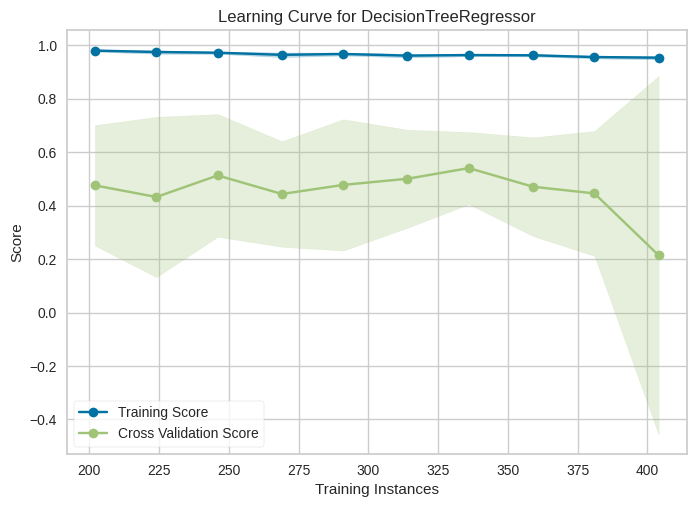

In [ ]:
visualizer = LearningCurve(
    DecisionTreeRegressor(max_depth=6), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show()

## 3. Дополните анализ датасета Бостон исследованием модели лассо - постройте кривые обучения для переобученной, недообученной и качественной модели, найдите оптимальное значение параметра регуляризации в модели лассо.

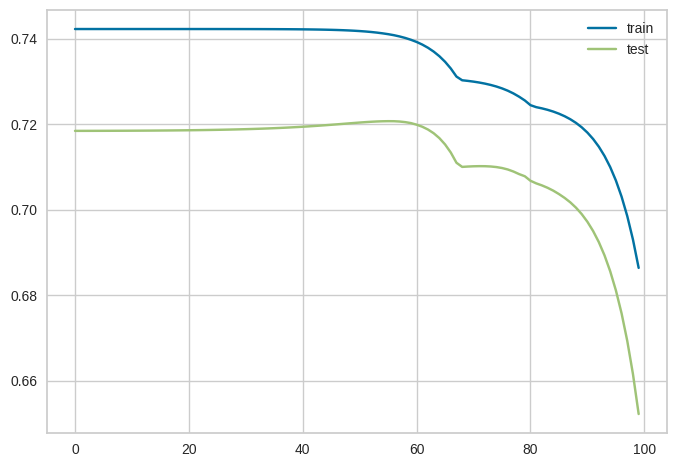

In [ ]:
from sklearn.linear_model import Lasso
trains = []
tests = []
for i in np.logspace(-4, 0, 100):
    ridge = Lasso(alpha=i).fit(X_train, y_train)
    trains.append(ridge.score(X_train, y_train))
    tests.append(ridge.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend();

In [ ]:
np.logspace(-4, 0, 100)[60]

np.float64(0.026560877829466867)

In [ ]:
ridge_underfitting = Lasso(alpha=1).fit(X_train, y_train)
ridge_overfitting = Lasso(alpha=0).fit(X_train, y_train)
ridge_good = Lasso(alpha=0.02656).fit(X_train, y_train)

print(f"Training score: {ridge_underfitting.score(X_train, y_train):.4f}")
print(f"Test score: {ridge_underfitting.score(X_test, y_test):.4f}")

print(f"Training score: {ridge_overfitting.score(X_train, y_train):.4f}")
print(f"Test score: {ridge_overfitting.score(X_test, y_test):.4f}")

print(f"Training score: {ridge_good.score(X_train, y_train):.4f}")
print(f"Test score: {ridge_good.score(X_test, y_test):.4f}")

Training score: 0.6864
Test score: 0.6522
Training score: 0.7422
Test score: 0.7184
Training score: 0.7392
Test score: 0.7199


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.669e+03, tolerance: 3.623e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

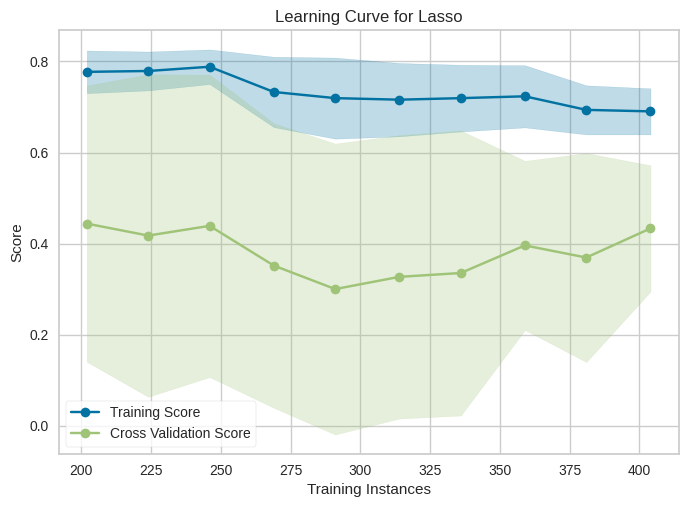

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.076e+03, tolerance: 1.869e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

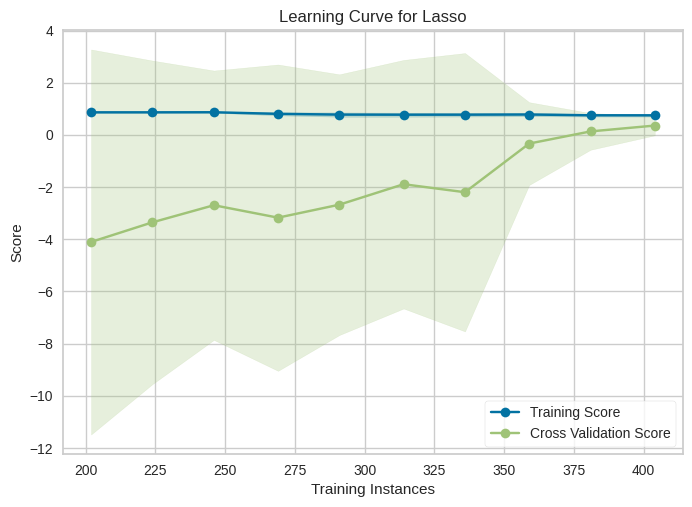

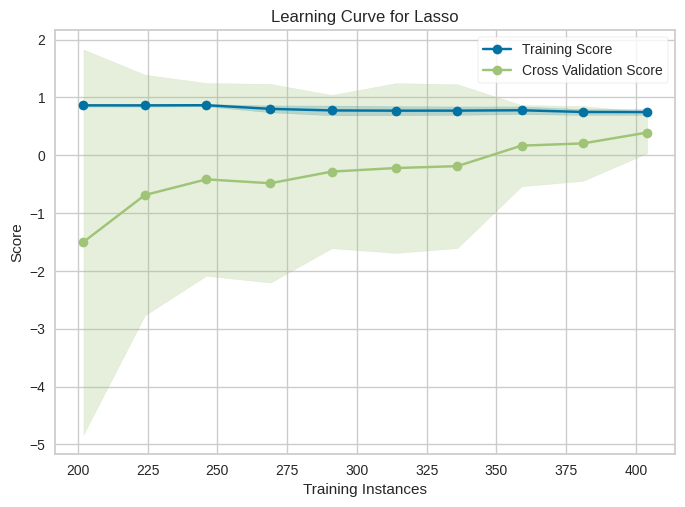

In [ ]:
visualizer = LearningCurve(
    Lasso(alpha=1), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show()

visualizer = LearningCurve(
    Lasso(alpha=0), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show()

visualizer = LearningCurve(
    Lasso(alpha=0.02656), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show()

## 4. В одном из двух первых примеров используйте модель ElasticNet и исследуйте влияние сразу двух параметров регуляризации на эффективность модели.

In [ ]:
from sklearn.linear_model import ElasticNet

alphas = [0.1, 0.5, 1.0, 2.0]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

for alpha in alphas:
    for l1_ratio in l1_ratios:
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
        model.fit(X_train, y_train)

        print(f"Alpha: {alpha}, L1 Ratio: {l1_ratio}")
        print(f"Training score: {model.score(X_train, y_train):.4f}")
        print(f"Test score: {model.score(X_test, y_test):.4f}")
        print("-----------------------------------------")

Alpha: 0.1, L1 Ratio: 0.1
Training score: 0.7263
Test score: 0.7051
-----------------------------------------
Alpha: 0.1, L1 Ratio: 0.3
Training score: 0.7268
Test score: 0.7061
-----------------------------------------
Alpha: 0.1, L1 Ratio: 0.5
Training score: 0.7272
Test score: 0.7069
-----------------------------------------
Alpha: 0.1, L1 Ratio: 0.7
Training score: 0.7278
Test score: 0.7080
-----------------------------------------
Alpha: 0.1, L1 Ratio: 0.9
Training score: 0.7284
Test score: 0.7093
-----------------------------------------
Alpha: 0.5, L1 Ratio: 0.1
Training score: 0.7063
Test score: 0.6771
-----------------------------------------
Alpha: 0.5, L1 Ratio: 0.3
Training score: 0.7068
Test score: 0.6783
-----------------------------------------
Alpha: 0.5, L1 Ratio: 0.5
Training score: 0.7080
Test score: 0.6805
-----------------------------------------
Alpha: 0.5, L1 Ratio: 0.7
Training score: 0.7102
Test score: 0.6840
-----------------------------------------
Alpha: 0.5

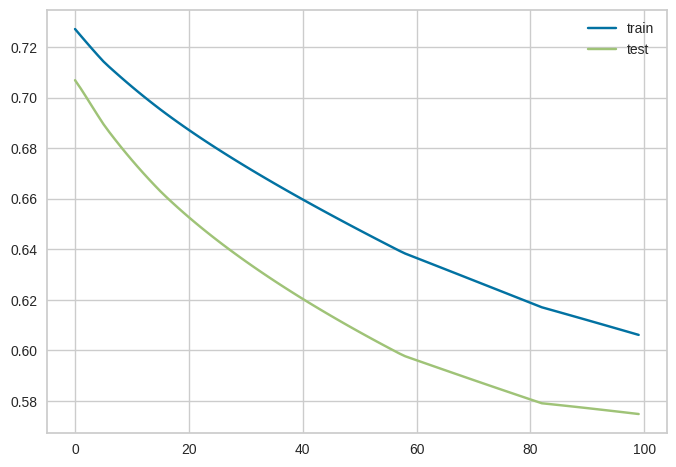

In [ ]:
trains = []
tests = []
for i in np.linspace(0.1, 5, 100):
    model = ElasticNet(alpha=i).fit(X_train, y_train)
    trains.append(model.score(X_train, y_train))
    tests.append(model.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend();

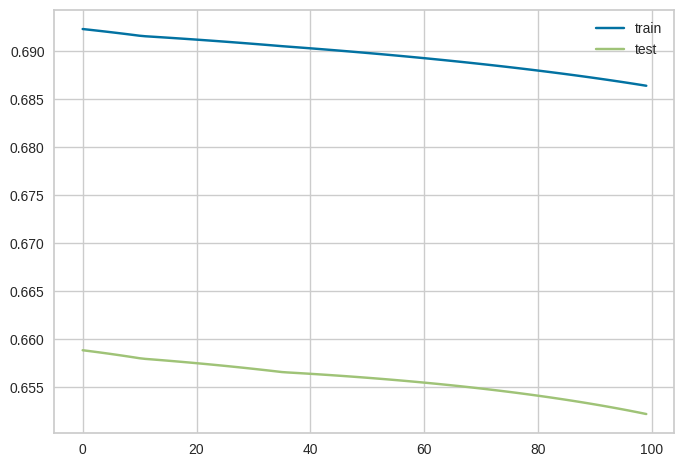

In [ ]:
trains = []
tests = []
for i in np.linspace(0.1, 1, 100):
    model = ElasticNet(l1_ratio=i).fit(X_train, y_train)
    trains.append(model.score(X_train, y_train))
    tests.append(model.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend();

In [ ]:
model = ElasticNet(alpha=0.1, l1_ratio=1, random_state=42)
model.fit(X_train, y_train)

print(f"Training score: {model.score(X_train, y_train):.4f}")
print(f"Test score: {model.score(X_test, y_test):.4f}")

Training score: 0.7287
Test score: 0.7099


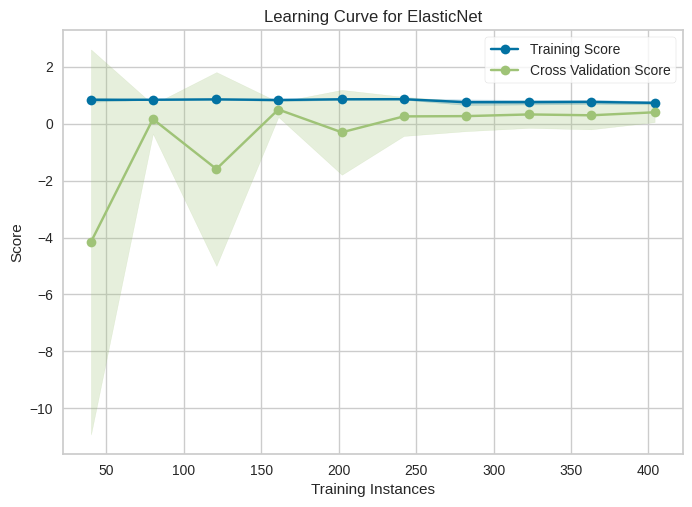

In [ ]:
visualizer = LearningCurve(
    ElasticNet(alpha=0.1, l1_ratio=1, random_state=42), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

## 5. Дополните анализ дерева решений из третьего примера: постройте кривые регуляризации для полного датасета, найдите оптимальную глубину дерева и оцените качество такой модели на всем датасете. Повторите данный анализ используя в качестве метрики эффективности F1.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 1.0000
Test score = 0.7273


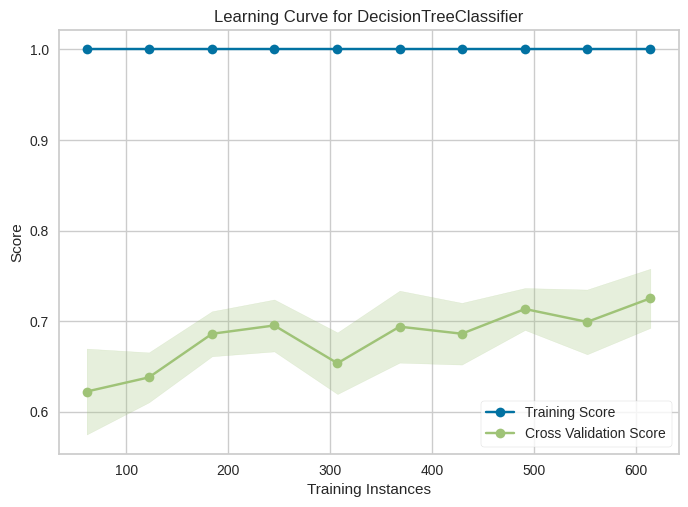

In [ ]:
visualizer = LearningCurve(
    DecisionTreeClassifier(random_state=1), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

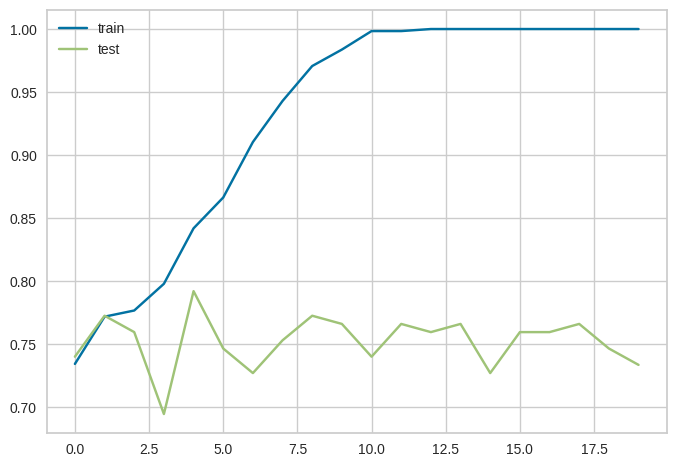

In [ ]:
trains = []
tests = []
for i in np.linspace(1, 20, 20):
    model = DecisionTreeClassifier(max_depth=int(i)).fit(X_train, y_train)
    trains.append(model.score(X_train, y_train))
    tests.append(model.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend();

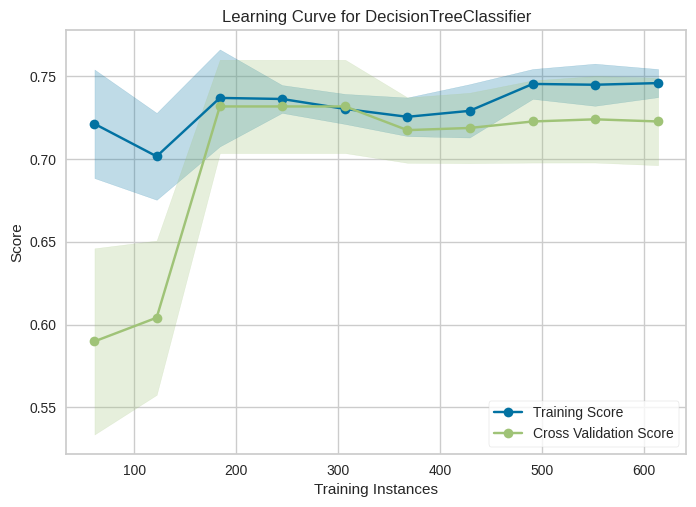

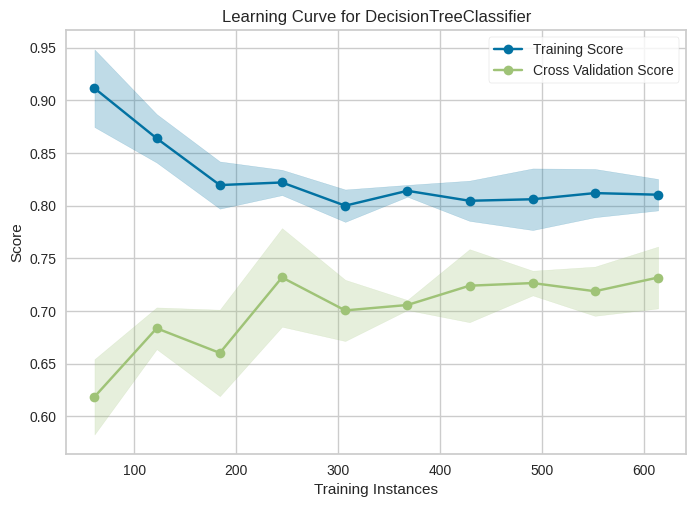

In [ ]:
visualizer = LearningCurve(
    DecisionTreeClassifier(max_depth=1), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

visualizer = LearningCurve(
    DecisionTreeClassifier(max_depth=4), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

In [ ]:
print("Train f1_score = %.4f" % f1_score(y_train, y_train_pred))
print("Test f1_score = %.4f" % f1_score(y_test, y_pred))

Train f1_score = 1.0000
Test f1_score = 0.6379


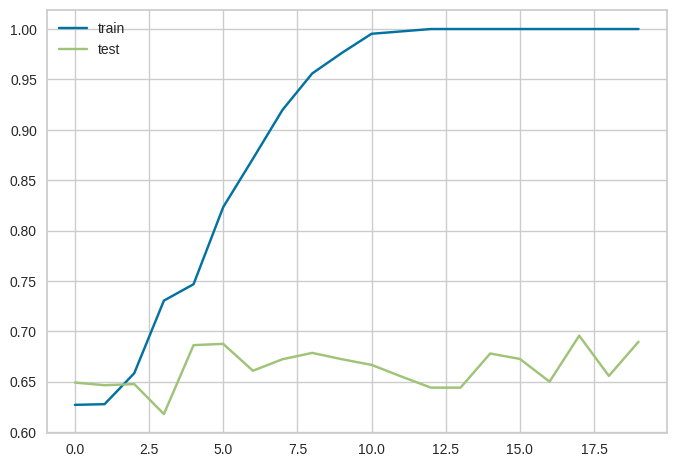

In [ ]:
trains = []
tests = []
for i in np.linspace(1, 20, 20):
    model = DecisionTreeClassifier(max_depth=int(i)).fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    trains.append(f1_score(y_train, y_train_pred))
    tests.append(f1_score(y_test, y_pred))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend();

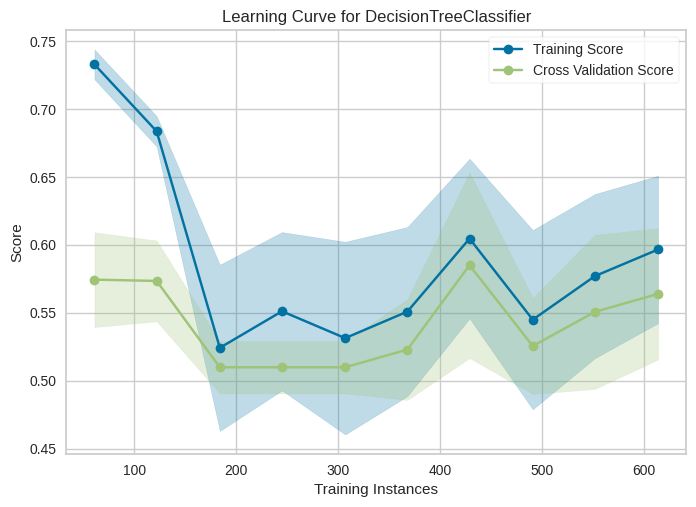

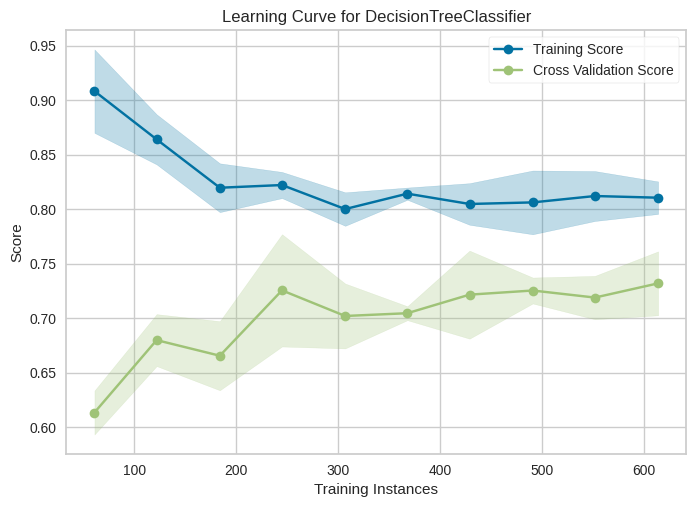

In [ ]:
visualizer = LearningCurve(
    DecisionTreeClassifier(max_depth=1),
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

visualizer = LearningCurve(
    DecisionTreeClassifier(max_depth=4), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

## 6. Повторите анализ на других реальных датасетах из репозитория OpenML:
- phoneme
- banknote-authentication
- delta_ailerons
- mammography
- electricity
- mozilla4
- kropt
- nursery
- volcanoes-b3

In [ ]:
from sklearn.datasets import fetch_openml
data = fetch_openml(name='phoneme', parser="auto")

X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

/usr/local/lib/python3.11/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name phoneme exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1489
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43973

  warn(warning_msg)


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.7543
Test score = 0.7401


In [ ]:
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import PolynomialFeatures

model = RidgeClassifier(alpha=0.001).fit(PolynomialFeatures(5).fit_transform(X_train), y_train)
y_train_pred = model.predict(PolynomialFeatures(5).fit_transform(X_train))
y_pred = model.predict(PolynomialFeatures(5).fit_transform(X_test))
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.8765
Test score = 0.8566


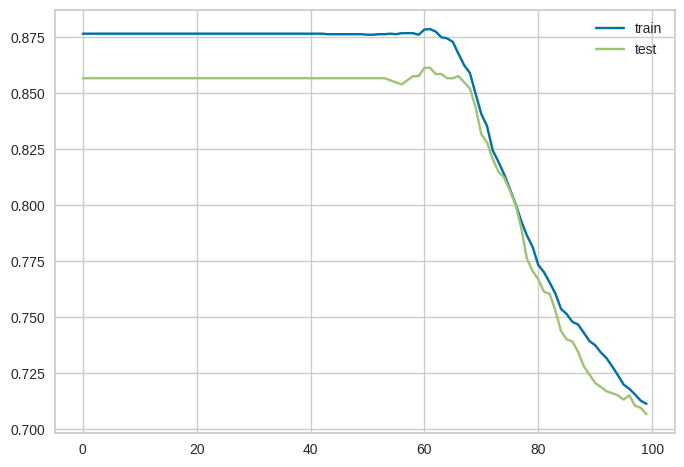

In [ ]:
trains = []
tests = []
for k, i in enumerate(np.logspace(-8, 7, 100)):
    ridge = RidgeClassifier(alpha=i).fit(PolynomialFeatures(5).fit_transform(X_train), y_train)
    trains.append(ridge.score(PolynomialFeatures(5).fit_transform(X_train), y_train))
    tests.append(ridge.score(PolynomialFeatures(5).fit_transform(X_test), y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

In [ ]:
model = RidgeClassifier(alpha=12.328).fit(PolynomialFeatures(5).fit_transform(X_train), y_train)
y_train_pred = model.predict(PolynomialFeatures(5).fit_transform(X_train))
y_pred = model.predict(PolynomialFeatures(5).fit_transform(X_test))
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.8783
Test score = 0.8612


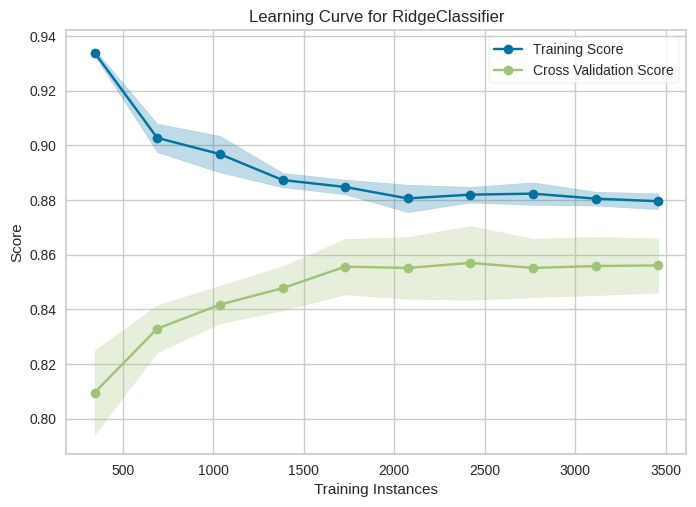

In [ ]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=12.328), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(PolynomialFeatures(5).fit_transform(X_train), y_train).show()

In [ ]:
data = fetch_openml(name='banknote-authentication', parser="auto")

X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9900
Test score = 0.9927


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
Valu

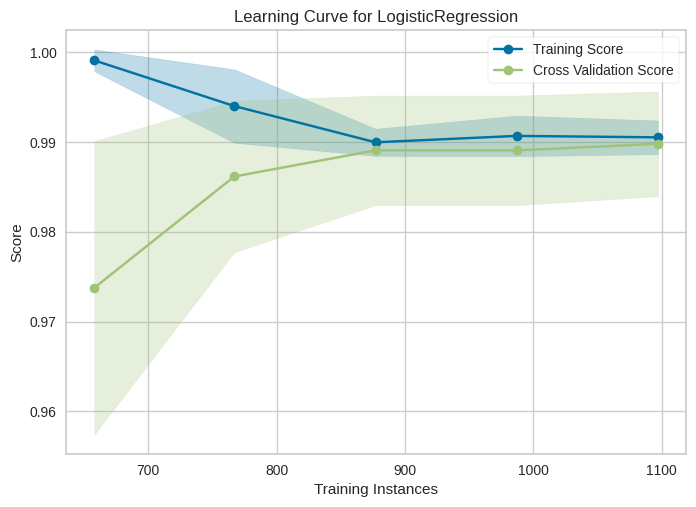

In [ ]:
visualizer = LearningCurve(
    LogisticRegression(), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X,y).show()

In [ ]:
data = fetch_openml(name='delta_ailerons', parser="auto")

X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.6092
Test score = 0.5989


In [ ]:
model = RidgeClassifier(alpha=0.001).fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
y_train_pred = model.predict(PolynomialFeatures(2).fit_transform(X_train))
y_pred = model.predict(PolynomialFeatures(2).fit_transform(X_test))
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9392
Test score = 0.9362


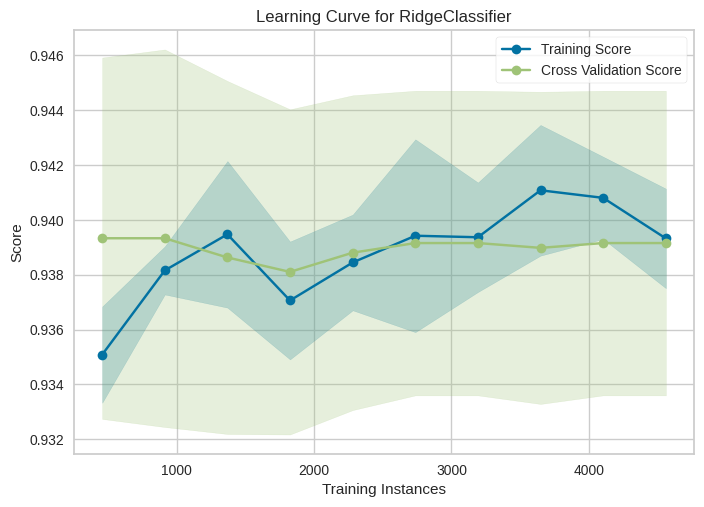

In [ ]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=0.001), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(PolynomialFeatures(2).fit_transform(X_train), y_train).show()

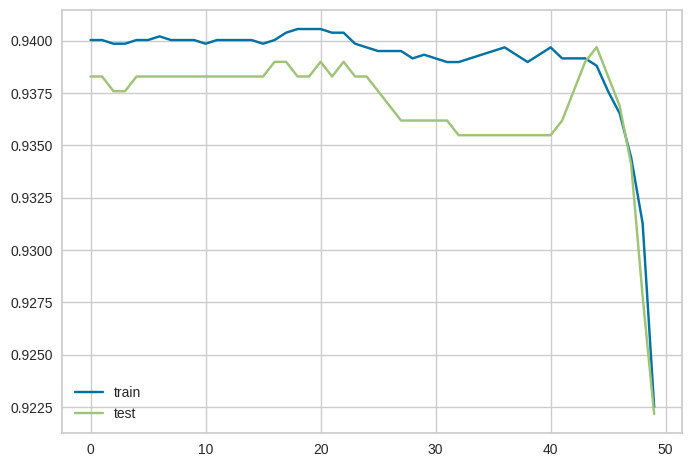

In [ ]:
trains = []
tests = []
for k, i in enumerate(np.logspace(-7, 0, 50)):
    ridge = RidgeClassifier(alpha=i).fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
    trains.append(ridge.score(PolynomialFeatures(2).fit_transform(X_train), y_train))
    tests.append(ridge.score(PolynomialFeatures(2).fit_transform(X_test), y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

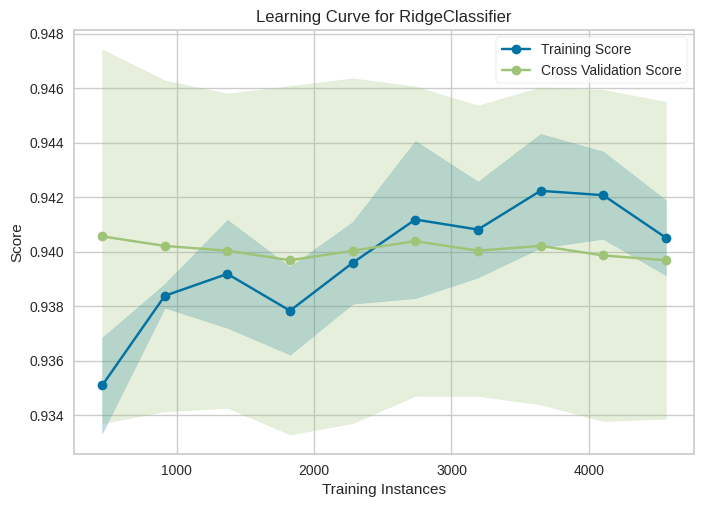

In [ ]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=3.727593720314938e-05), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(PolynomialFeatures(2).fit_transform(X_train), y_train).show()